# Fake News Detection using Machine Learning

## Objective
Build a machine learning model capable of distinguishing between real and fake news articles.

## Dataset
- Fake.csv
- True.csv

## Models Compared
- Naive Bayes
- Random Forest
- Linear SVM

## Final Model
Linear SVM with TF-IDF Vectorization

# Dataset Loading

In this section we load both fake and real news datasets and merge them into a single dataframe.

In [1]:
import pandas as pd
fake = pd.read_csv("/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/Fake.csv")
true = pd.read_csv("/kaggle/input/datasets/clmentbisaillon/fake-and-real-news-dataset/True.csv")

# Exploratory Data Analysis

We explore:
- Class distribution
- Text length distribution
- Word frequencies
- Word clouds

In [2]:
fake.shape,true.shape

((23481, 4), (21417, 4))

In [3]:
fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [4]:
true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
fake["label"] = 0
true["label"] = 1

In [6]:
fake = fake.drop(columns=["subject","date"])
true = true.drop(columns=["subject","date"])

In [7]:
df = pd.concat(
    [fake,true],
    ignore_index=True
)

In [8]:
df = df.sample(
    frac=1,
    random_state=42 
).reset_index(drop=True)

In [9]:
df.shape

(44898, 3)

In [10]:
df["content"] = (
    df["title"]
    + " "
    + df["text"]
)

In [11]:
df[
    [
        "content",
        "label"
    ]
].head()

,content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   label    44898 non-null  int64 
 3   content  44898 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.4+ MB


In [13]:
df.isnull().sum()

title      0
text       0
label      0
content    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(5793)

In [15]:
df = df.drop_duplicates()

# Text Preprocessing

The preprocessing pipeline includes:
- Lowercasing
- URL removal
- Punctuation removal
- Stopword removal
- Reuters boilerplate removal

In [16]:
df["char_count"] = df["content"].apply(len)

In [17]:
df["word_count"] = df["content"].apply(
    lambda x: len(x.split())
)

In [18]:
import nltk
nltk.download("punkt")

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
from nltk.tokenize import sent_tokenize

df["sentence_count"] = df["content"].apply(
    lambda x: len(sent_tokenize(x))
)

In [20]:
df["label"].value_counts()

label
1    21197
0    17908
Name: count, dtype: int64

In [21]:
df.groupby("label")[
    [
        "char_count",
        "word_count",
        "sentence_count"
    ]
].mean()

,char_count,word_count,sentence_count
label,,,
0,2578.704601,429.015077,15.214876
1,2444.356277,394.814644,14.799641


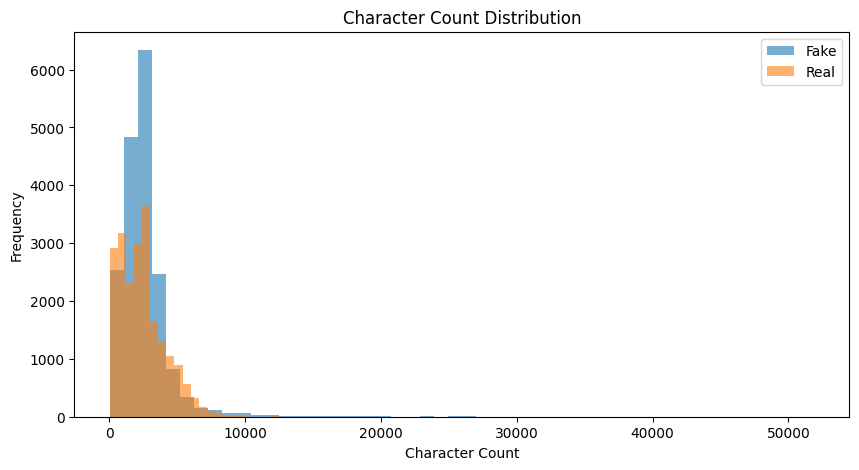

In [22]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,5))
plt.hist(
    df[df["label"] == 0]["char_count"],
    bins=50,
    alpha=0.6,
    label="Fake"
)

plt.hist(
    df[df["label"] == 1]["char_count"],
    bins=50,
    alpha=0.6,
    label="Real"
)

plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.title("Character Count Distribution")
plt.legend()
plt.show()

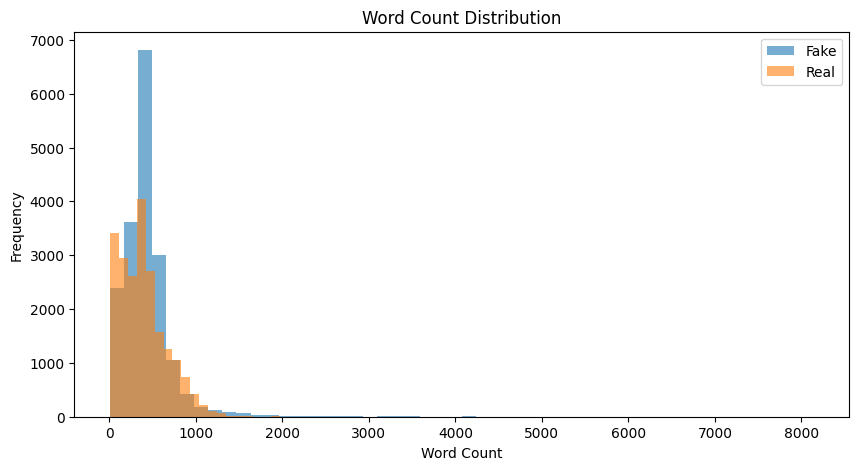

In [23]:
plt.figure(figsize=(10,5))

plt.hist(
    df[df["label"] == 0]["word_count"],
    bins=50,
    alpha=0.6,
    label="Fake"
)

plt.hist(
    df[df["label"] == 1]["word_count"],
    bins=50,
    alpha=0.6,
    label="Real"
)

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Word Count Distribution")
plt.legend()

plt.show()

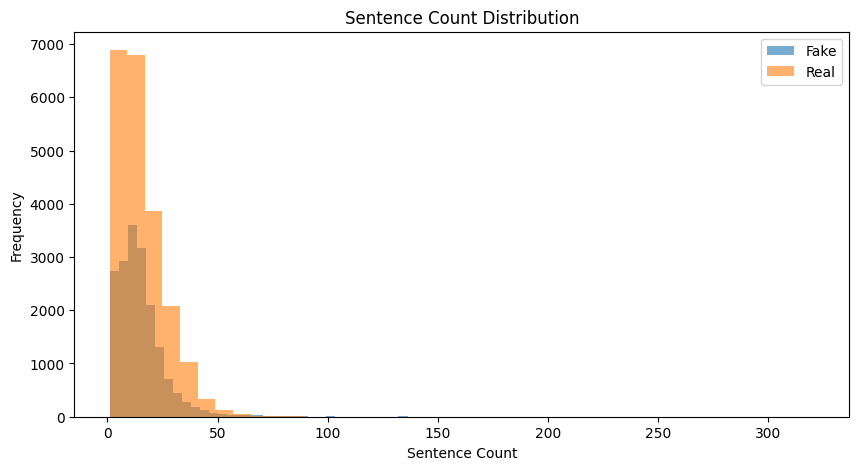

In [24]:
plt.figure(figsize=(10,5))

plt.hist(
    df[df["label"] == 0]["sentence_count"],
    bins=70,
    alpha=0.6,
    label="Fake"
)

plt.hist(
    df[df["label"] == 1]["sentence_count"],
    bins=40,
    alpha=0.6,
    label="Real"
)

plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.title("Sentence Count Distribution")
plt.legend()

plt.show()

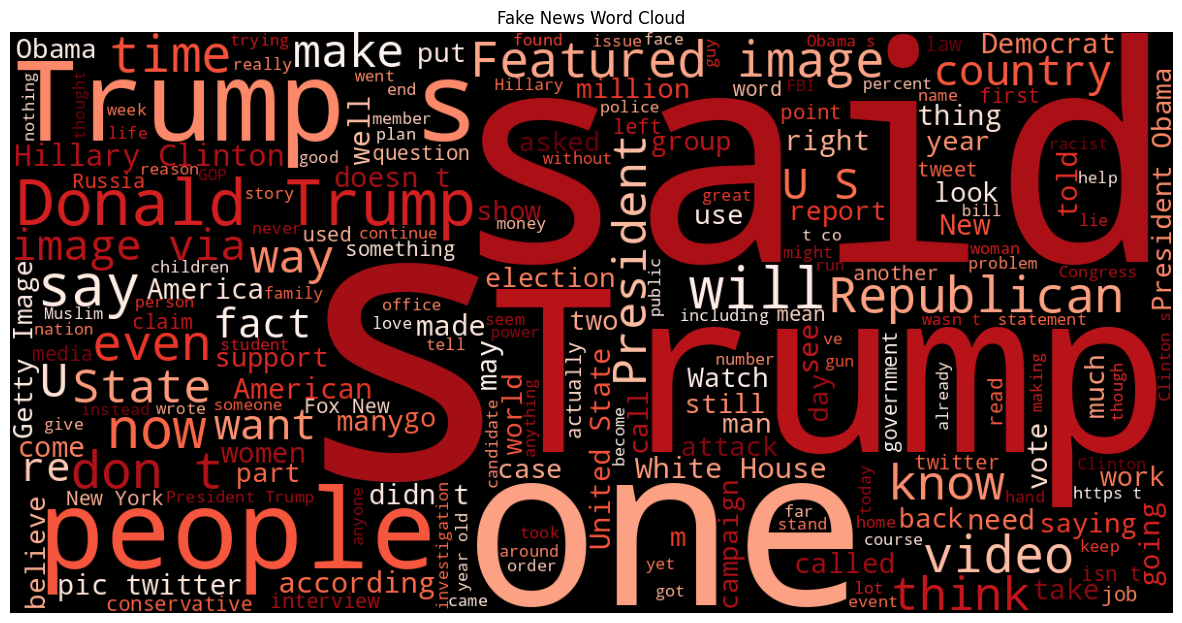

In [25]:
from wordcloud import WordCloud

fake_text = " ".join(
    df[df["label"]==0]["content"]
)

wc = WordCloud(
    width=1200,
    height=600,
    background_color="black",
    colormap="Reds"
)

plt.figure(figsize=(15,8))

plt.imshow(wc.generate(fake_text))

plt.axis("off")
plt.title("Fake News Word Cloud")

plt.show()

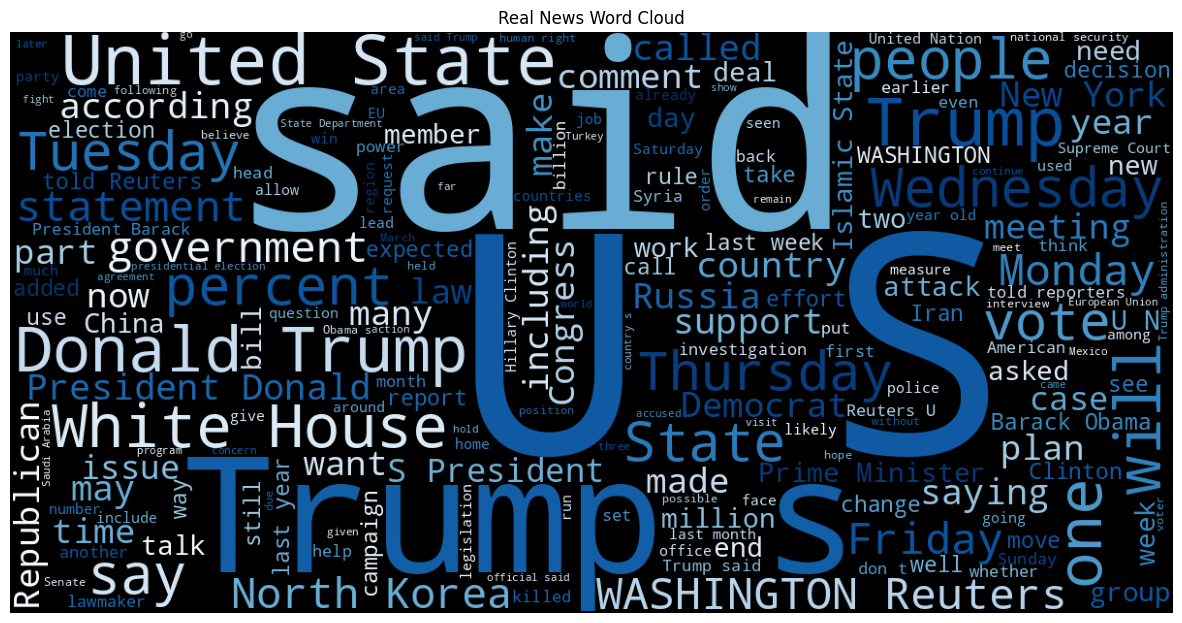

In [26]:
real_text = " ".join(
    df[df["label"]==1]["content"]
)

wc = WordCloud(
    width=1200,
    height=600,
    background_color="black",
    colormap="Blues"
)

plt.figure(figsize=(15,8))

plt.imshow(wc.generate(real_text))

plt.axis("off")
plt.title("Real News Word Cloud")

plt.show()

In [27]:
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(
    stopwords.words("english")
)

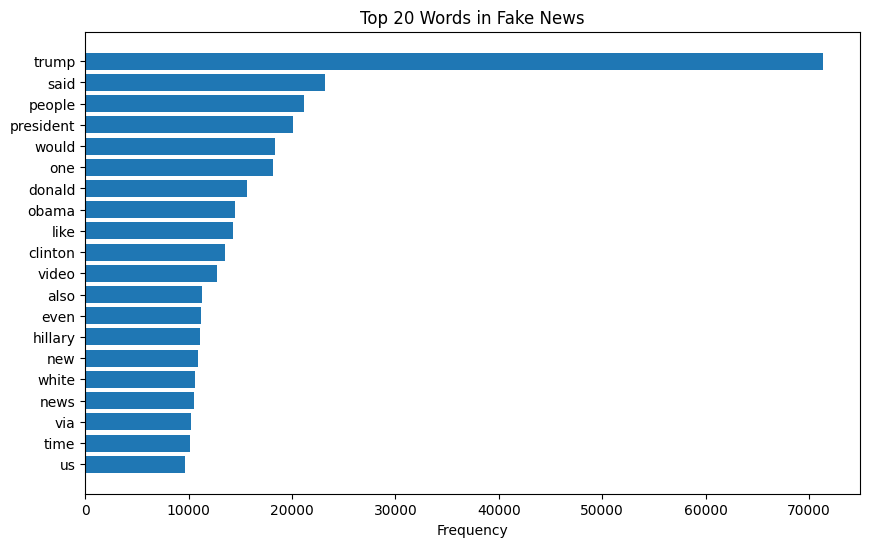

In [28]:
fake_words = [
    word.lower()
    for word in word_tokenize(fake_text)
    if word.isalpha()
    and word.lower() not in stop_words
]

fake_counter = Counter(fake_words)

top_fake = fake_counter.most_common(20)

words = [x[0] for x in top_fake]
counts = [x[1] for x in top_fake]

plt.figure(figsize=(10,6))

plt.barh(
    words[::-1],
    counts[::-1]
)

plt.title("Top 20 Words in Fake News")
plt.xlabel("Frequency")

plt.show()

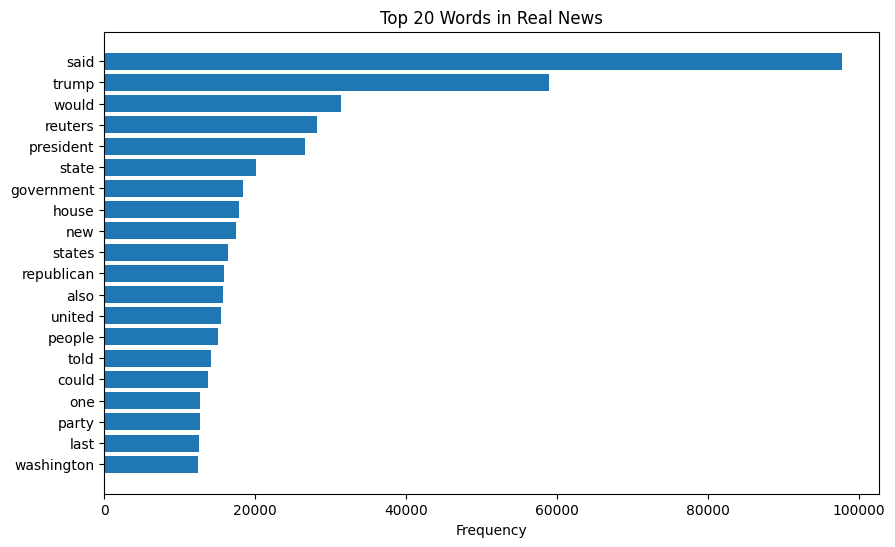

In [29]:
real_words = [
    word.lower()
    for word in word_tokenize(real_text)
    if word.isalpha()
    and word.lower() not in stop_words
]

real_counter = Counter(real_words)

top_real = real_counter.most_common(20)

words = [x[0] for x in top_real]
counts = [x[1] for x in top_real]

plt.figure(figsize=(10,6))

plt.barh(
    words[::-1],
    counts[::-1]
)

plt.title("Top 20 Words in Real News")
plt.xlabel("Frequency")

plt.show()

In [30]:
import re 
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

stop_words = set(
    stopwords.words("english")
)

ps = PorterStemmer()

In [31]:
import re
import string
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def preprocess(text):

    # convert to lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # remove html tags
    text = re.sub(r"<.*?>", "", text)

    # remove Reuters boilerplate
    text = re.sub(r"\(reuters\)\s*-", "", text)

    # remove punctuation
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    # remove digits
    text = re.sub(r"\d+", "", text)

    # tokenize and remove stopwords
    words = []

    for word in text.split():

        if word not in stop_words:
            words.append(word)

    return " ".join(words)

In [32]:
# Create clean text column
df["clean_text"] = df["content"].apply(preprocess)

# Features and target
X = df["clean_text"]
y = df["label"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF Vectorization

We convert text into numerical features using TF-IDF with:
- Unigrams
- Bigrams
- 20,000 features

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train)

# IMPORTANT: transform, NOT fit_transform
X_test_tfidf = tfidf.transform(X_test)

# Model Benchmarking

The following models are evaluated:
- Multinomial Naive Bayes
- Random Forest
- Linear Support Vector Machine

In [35]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train_tfidf,
    y_train
)

y_pred = lr.predict(
    X_test_tfidf
)

In [36]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))
print("F1 Score:",f1_score(y_test,y_pred))

Accuracy: 0.9831223628691983
Precision: 0.9805757079335362
Recall: 0.9884406699693324
F1 Score: 0.9844924812030075


In [37]:
feature_names = tfidf.get_feature_names_out()

coefficients = lr.coef_[0]

In [38]:
top_real = sorted(
    zip(coefficients, feature_names),
    reverse=True
)[:20]

print("Top Real News Words:\n")

for coef, word in top_real:
    print(f"{word}: {coef:.4f}")

Top Real News Words:

said: 18.6442
washington: 7.2644
reuters: 6.2331
president donald: 6.1849
wednesday: 5.5520
tuesday: 5.5087
thursday: 5.1175
friday: 4.5683
republican: 4.4243
monday: 4.3616
don: 3.7330
said statement: 3.6584
minister: 3.6437
nov: 3.5803
washington president: 3.3682
presidential: 3.3257
told reuters: 3.3022
spokesman: 3.2210
president barack: 3.2076
democratic: 3.0398


In [39]:
top_fake = sorted(
    zip(coefficients, feature_names)
)[:20]

print("Top Fake News Words:\n")

for coef, word in top_fake:
    print(f"{word}: {coef:.4f}")

Top Fake News Words:

video: -10.3664
image: -7.3535
gop: -6.1565
hillary: -5.8561
images: -5.2842
president trump: -5.1254
like: -5.0034
america: -4.3938
obama: -4.2633
mr: -4.1990
watch: -4.0500
breaking: -3.7075
know: -3.7055
president obama: -3.5252
fact: -3.5238
rep: -3.4979
wire: -3.4712
american: -3.2822
isis: -3.2615
really: -3.2334


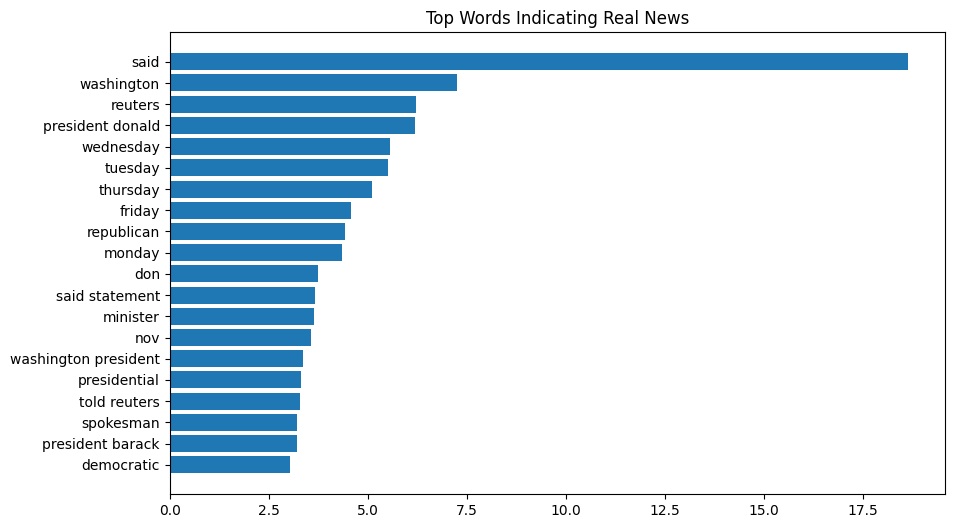

In [40]:
real_words = [x[1] for x in top_real]
real_scores = [x[0] for x in top_real]

plt.figure(figsize=(10,6))
plt.barh(real_words[::-1], real_scores[::-1])
plt.title("Top Words Indicating Real News")
plt.show()

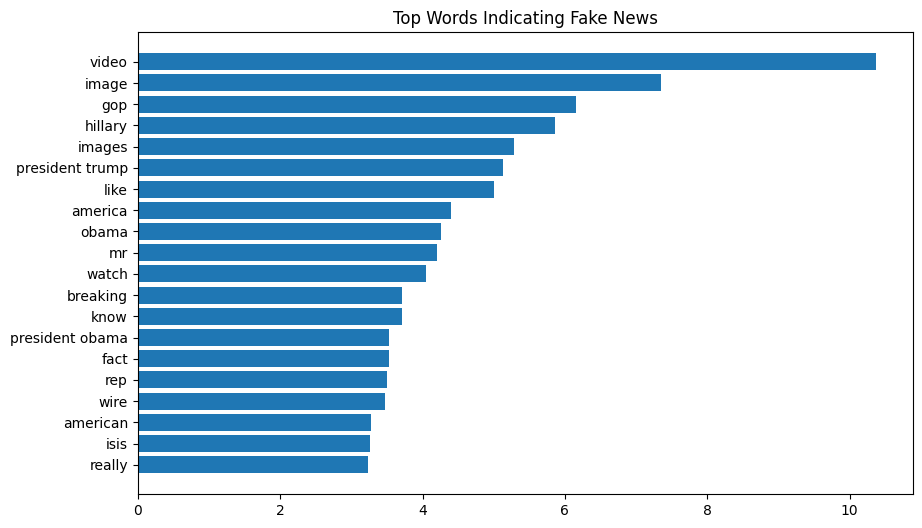

In [41]:
fake_words = [x[1] for x in top_fake]
fake_scores = [abs(x[0]) for x in top_fake]

plt.figure(figsize=(10,6))
plt.barh(fake_words[::-1], fake_scores[::-1])
plt.title("Top Words Indicating Fake News")
plt.show()

In [42]:
from sklearn.model_selection import cross_val_score

results = []

def evaluate_model(name,model):
    model.fit(X_train_tfidf,y_train)
    y_pred = model.predict(X_test_tfidf)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    
    cv = cross_val_score(
        model,
        X_train_tfidf,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    results.append({
        "Model":name,
        "Precision":precision,
        "Recall":recall,
        "F1 Score":f1,
        "CV Mean":cv.mean(),
        "CV Std":cv.std()
    })
    print(f"\n{name}")
    print(f"Precision:{precision:.4f}")
    print(f"Recall:{recall:.4f}")
    print(f"F1 Score:{f1:.4f}")
    print(f"CV Mean:{cv.mean():.4f}")
    print(f"CV Std:{cv.std():.4f}")

In [43]:
evaluate_model("Logistic Regression",LogisticRegression(max_iter=1000))


Logistic Regression
Precision:0.9806
Recall:0.9884
F1 Score:0.9845
CV Mean:0.9815
CV Std:0.0014


In [44]:
from sklearn.naive_bayes import MultinomialNB
evaluate_model("Naive Bayes",MultinomialNB())


Naive Bayes
Precision:0.9572
Recall:0.9398
F1 Score:0.9485
CV Mean:0.9465
CV Std:0.0029


In [45]:
from sklearn.svm import LinearSVC
evaluate_model("SVM",LinearSVC())


SVM
Precision:0.9866
Recall:0.9927
F1 Score:0.9897
CV Mean:0.9887
CV Std:0.0017


In [46]:
from sklearn.ensemble import RandomForestClassifier
evaluate_model("Random Forest",RandomForestClassifier(random_state=42))


Random Forest
Precision:0.9753
Recall:0.9854
F1 Score:0.9803
CV Mean:0.9786
CV Std:0.0020


In [47]:
from sklearn.calibration import CalibratedClassifierCV

svm = LinearSVC()

calibrated_svm = CalibratedClassifierCV(
    svm,
    cv=5
)

evaluate_model("Calibrated SVM",calibrated_svm)


Calibrated SVM
Precision:0.9901
Recall:0.9903
F1 Score:0.9902
CV Mean:0.9887
CV Std:0.0021


In [48]:
def predict_message(text):

    cleaned_text = preprocess(text)

    vectorized_text = tfidf.transform(
        [cleaned_text]
    )

    prediction = calibrated_svm.predict(
        vectorized_text
    )[0]

    probabilities = calibrated_svm.predict_proba(
        vectorized_text
    )[0]

    if prediction == 1:
        confidence = probabilities[1] * 100

        print(
            f"🟢 REAL NEWS ({confidence:.2f}%)"
        )

    else:
        confidence = probabilities[0] * 100

        print(
            f"🔴 FAKE NEWS ({confidence:.2f}%)"
        )

In [49]:
predict_message(
    """
    NASA successfully launched a new satellite
    into orbit yesterday.
    """
)

🔴 FAKE NEWS (95.26%)


In [50]:
predict_message(
    """
    Scientists confirm that lizard people secretly
    control world governments.
    """
)

🔴 FAKE NEWS (83.81%)


In [51]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Precision,Recall,F1 Score,CV Mean,CV Std
4,Calibrated SVM,0.990094,0.990328,0.990211,0.988748,0.002137
2,SVM,0.986635,0.992687,0.989652,0.988652,0.001713
0,Logistic Regression,0.980576,0.988441,0.984492,0.981492,0.001428
3,Random Forest,0.975251,0.985374,0.980286,0.978615,0.001970
1,Naive Bayes,0.957232,0.939844,0.948459,0.946458,0.002927


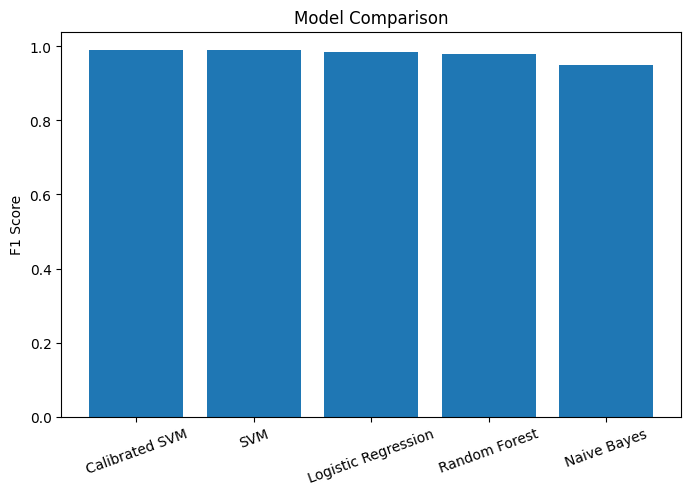

In [52]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.title("Model Comparison")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)

plt.show()

# Conclusion

Linear SVM achieved the best performance with an F1 score of 98.97%.

The project demonstrates:
- NLP preprocessing
- TF-IDF vectorization
- Model comparison
- Cross-validation
- Classical machine learning for text classification

In [53]:
import joblib 
best_model = calibrated_svm
joblib.dump(best_model,"calibrated_svm_model.pkl")

joblib.dump(tfidf,"tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']